<a href="https://colab.research.google.com/github/cristinadias360-afk/Cristina-Dias/blob/main/MVP_ML_%26_Analytics_Credito_Risco_Cristina_Silva_Dias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# MVP — Machine Learning & Analytics
## Classificação de Inadimplência em Crédito: Modelos Tradicionais vs. Modelos baseados em Árvore com Explicabilidade (XAI/SHAP)

**Autora:** Cristina Silva Dias

**Data:** 11/06/2026

**Matrícula:** 4052026000923

**Dataset:** [Credit Risk Dataset (Kaggle)](https://www.kaggle.com/datasets/laotse/credit-risk-dataset)


## ✅ Checklist do MVP

| Item | Status | Evidência |
|---|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | ✅ | Seção 1 — escopo, contexto de negócio, tipo de tarefa (classificação binária) e pergunta de pesquisa |
| Dataset descrito, com fonte, atributos e restrições | ✅ | Seção 3 — fonte (Kaggle), dicionário de variáveis, restrições discutidas (ausência de chave única, dados estáticos) |
| Dataset carregado por URL pública ou fonte diretamente acessível | ✅ | Seção 3 — `pd.read_csv` direto via `raw.githubusercontent.com` |
| Análise exploratória objetiva, conectada à modelagem | ✅ | Seção 3.2 — distribuições, taxas de inadimplência por categoria e insights ligados diretamente às features usadas na modelagem |
| Divisão adequada em treino/teste e, se aplicável, validação | ✅ | Seção 4 — split 80/20 estratificado (justificado); Seção 7 — `StratifiedKFold` na validação cruzada |
| Prevenção de vazamento de dados | ✅ | Seção 4/5 — split antes de qualquer ajuste; imputação/encoding/escala dentro do `Pipeline`, aprendidos só no treino |
| Tratamentos de dados justificados | ✅ | Seção 3.2.1 — substituição de valores implausíveis pela média; Seção 5 — justificativa da estratégia de imputação (mediana/moda) |
| Pipeline ou sequência reprodutível de pré-processamento | ✅ | Seção 5 — `ColumnTransformer` + `Pipeline`, com `SEED` fixo (Seção 2) |
| Modelo baseline definido | ✅ | Seção 6 — `DummyClassifier` |
| Pelo menos dois modelos/abordagens comparados | ✅ | Seção 6 — Regressão Logística vs. Random Forest, Gradient Boosting, XGBoost, LightGBM; Seção 6.2 — ablação de *features* |
| Ajuste de hiperparâmetros em pelo menos um modelo | ✅ | Seção 7 — `RandomizedSearchCV` na Regressão Logística e no melhor modelo em árvore |
| Avaliação com métricas coerentes com o problema | ✅ | Seções 6.1/8 — ROC-AUC, KS, PR-AUC, F1, Recall, Precision (adequadas ao desbalanceamento) |
| Discussão de overfitting/underfitting, limitações e melhorias | ✅ | Seção 8.1 — gap treino vs. teste (ROC-AUC, F1, KS); Seção 8.3/11 — limitações e próximos passos |
| Código limpo, organizado e executável do início ao fim | ✅ | Notebook testado e executado sem erros |
| Conclusão conectada ao objetivo inicial | ✅ | Seção 11 — retoma o objetivo do MVP|
| Explicabilidade (XAI) | ✅ | Seção 9 — SHAP global (beeswarm) e local (waterfall), confrontado com os coeficientes da Regressão Logística (Seção 9.3) |


##1 Escopo, objetivo e definição do problema

No mercado financeiro, a adoção de algoritmos complexos de Machine Learning para a classificação de clientes inadimplentes esbarra na exigência regulatória e de governança por modelos transparentes, o que historicamente mantém a Regressão Logística como o padrão de mercado devido à sua alta interpretabilidade.

O objetivo deste MVP é desenvolver um framework preditivo que confronte esse modelo tradicional com algoritmos baseados em árvores (Random Forest, Gradient Boosting, XGBoost e LightGBM), utilizando técnicas de **Inteligência Artificial Explicável (XAI)**, via método **SHAP**, para extrair explicabilidade **global** (o que o modelo aprendeu no agregado) e **local** (por que o modelo decidiu algo para um cliente específico).

- **Objetivo:** classificar clientes quanto ao risco de inadimplência.
- **Tipo de tarefa:** classificação binária supervisionada.
- **Área de aplicação:** crédito / risco financeiro.
- **Valor para o negócio:** o projeto viabiliza o uso seguro de modelos de alta performance, permitindo à instituição reduzir a inadimplência por meio de uma classificação de risco mais precisa (ganho de eficiência preditiva). Ao acoplar a explicabilidade do SHAP, o negócio ganha agilidade na homologação de modelos junto às áreas de Risco e Compliance, mitigando risco regulatório e fornecendo insumos transparentes para reprovação/aprovação de crédito ao cliente.



## 2 Reprodutibilidade e ambiente

Todas as sementes aleatórias (`SEED`) são fixadas para garantir que a divisão dos dados, o treinamento dos modelos e a busca de hiperparâmetros sejam reprodutíveis.


### 2.1 Bibliotecas utilizadas

In [170]:
# === Setup básico e reprodutibilidade ===
import os, random, time, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import randint, uniform, ks_2samp
from sklearn.base import clone

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score, roc_auc_score,
    average_precision_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)

# Modelos baseados em árvore (gradient boosting de última geração)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Explicabilidade (XAI)
import shap

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed global:", SEED)


Python: 3.12.13
Seed global: 42


### 2.2 Funções auxiliares

Definidas uma única vez aqui e reutilizadas no restante do notebook.

In [171]:
def evaluate_classification(y_true, y_pred, proba=None):
    """Calcula métricas de classificação relevantes para um problema desbalanceado
    de crédito, incluindo KS (Kolmogorov-Smirnov), muito usado em modelos de risco."""
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),   # Sensibilidade
        "F1": f1_score(y_true, y_pred),
    }

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    metrics["Specificity"] = tn / (tn + fp)

    if proba is not None:
        scores = proba[:, 1]
        metrics["ROC_AUC"] = roc_auc_score(y_true, scores)
        metrics["PR_AUC"] = average_precision_score(y_true, scores)
        metrics["KS"] = ks_2samp(scores[y_true == 0], scores[y_true == 1]).statistic

    return metrics


def fit_and_evaluate(name, pipe, X_train, y_train, X_test, y_test, results):
    t0 = time.time()
    pipe.fit(X_train, y_train)
    t1 = time.time()
    y_pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test) if hasattr(pipe, "predict_proba") else None
    metrics = evaluate_classification(y_test, y_pred, proba)
    metrics["train_time_s"] = round(t1 - t0, 3)
    results[name] = metrics
    return pipe



## 3 Dados: carga, entendimento e qualidade

**Fonte:** [Credit Risk Dataset — Kaggle](https://www.kaggle.com/datasets/laotse/credit-risk-dataset)

| Nome da Variável | Descrição |
| :--- | :--- |
| `person_age` | Idade |
| `person_income` | Renda anual |
| `person_home_ownership` | Situação de moradia |
| `person_emp_length` | Tempo de emprego (em anos) |
| `loan_intent` | Finalidade do empréstimo |
| `loan_grade` | Classificação de risco do empréstimo |
| `loan_amnt` | Valor do empréstimo |
| `loan_int_rate` | Taxa de juros |
| `loan_status` | Status do empréstimo (**target**): 0 = adimplente, 1 = inadimplente |
| `loan_percent_income` | Percentual da renda comprometido com o empréstimo |
| `cb_person_default_on_file` | Histórico de inadimplência |
| `cb_person_cred_hist_length` | Tempo de histórico de crédito |


In [172]:
# === Carga dos dados ===
url = 'https://raw.githubusercontent.com/cristinadias360-afk/Cristina-Dias/refs/heads/main/credit_risk_dataset.csv'
df = pd.read_csv(url, delimiter=',')
df.head()


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


### 3.1 Engenharia de atributos

Criação de variáveis derivadas com base em conhecimento de negócio de crédito, usando apenas informações disponíveis no momento da concessão (sem vazamento de dados / *data leakage*).

#### 3.1.1 Variáveis contínuas derivadas (Razões)

In [173]:
df['loan_income_ratio'] = df['loan_amnt'] / df['person_income']                       # Razão empréstimo/renda
df['loan_employment_ratio'] = df['loan_amnt'] / (df['person_emp_length'] + 1)          # Valor do empréstimo por ano de emprego
df['credit_history_age_ratio'] = df['cb_person_cred_hist_length'] / df['person_age']   # Tempo de crédito em relação à idade


#### 3.1.2 Variáveis categóricas/agrupamentos

Essas faixas são criadas tanto para facilitar a leitura da EDA quanto para uso como *features* adicionais na modelagem (Seção 4). Elas são funções determinísticas das variáveis contínuas que as originaram (`person_age`, `person_income`, `loan_amnt`, `loan_percent_income`), então, ao usar as duas versões (contínua + faixa) simultaneamente, é esperado algum grau de redundância/multicolinearidade entre elas. Dessa forma será avaliado como os modelos em árvore e de  Regressão Logística lidam com essa redundância. Iremos testar 3 cenários: (A) só contínuas, (B) só faixas, (C) as duas juntas.

In [174]:
# Faixa etária
df['age_group'] = pd.cut(
    df['person_age'], bins=[18, 25, 35, 45, 60, 100],
    labels=['18-25', '26-35', '36-45', '46-60', '60+']
)
# Faixa salarial (quintis) — convertida para categórica: o rótulo do quintil (0 a 4) é um
# grupo, não uma quantidade; mantê-lo como inteiro faria o pipeline tratá-lo como variável
# contínua e assumir uma relação linear entre "quintil 0" e "quintil 4", o que não é o caso.
df['income_group'] = pd.qcut(df['person_income'], q=5, labels=False).astype('category')
# Faixa do valor do empréstimo (quintis) — mesmo motivo acima
df['loan_group'] = pd.qcut(df['loan_amnt'], q=5, labels=False).astype('category')
# Faixa de comprometimento de renda
df['income_percent_group'] = pd.cut(
    df['loan_percent_income'], bins=[0, 0.10, 0.20, 0.30, 0.50, 1],
    labels=['Muito baixo', 'Baixo', 'Médio', 'Alto', 'Muito alto']
)


### 3.2 Análise exploratória (EDA)

#### 3.2.1 Verificações iniciais

In [175]:
# === Verificações iniciais ===
display(df.sample(5, random_state=SEED))
print("\nFormato:", df.shape)
print("\nTipos:")
print(df.dtypes)
print("\nValores ausentes por coluna:")
print(df.isna().sum())


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_income_ratio,loan_employment_ratio,credit_history_age_ratio,age_group,income_group,loan_group,income_percent_group
14668,24,28000,OWN,6.0,HOMEIMPROVEMENT,B,10000,10.37,0,0.36,N,2,0.357143,1428.571429,0.083333,18-25,0,2,Alto
24614,27,64000,RENT,0.0,PERSONAL,C,10000,15.27,0,0.16,Y,10,0.156250,10000.000000,0.370370,26-35,3,2,Baixo
11096,26,72000,MORTGAGE,10.0,EDUCATION,D,16000,NaN,0,0.22,N,3,0.222222,1454.545455,0.115385,26-35,3,4,Médio
10424,23,27996,RENT,7.0,DEBTCONSOLIDATION,A,10000,NaN,1,0.36,N,2,0.357194,1250.000000,0.086957,18-25,0,2,Alto
26007,30,44500,RENT,2.0,MEDICAL,E,13000,16.32,1,0.29,N,6,0.292135,4333.333333,0.200000,26-35,1,3,Médio



Formato: (32581, 19)

Tipos:
person_age                       int64
person_income                    int64
person_home_ownership           object
person_emp_length              float64
loan_intent                     object
loan_grade                      object
loan_amnt                        int64
loan_int_rate                  float64
loan_status                      int64
loan_percent_income            float64
cb_person_default_on_file       object
cb_person_cred_hist_length       int64
loan_income_ratio              float64
loan_employment_ratio          float64
credit_history_age_ratio       float64
age_group                     category
income_group                  category
loan_group                    category
income_percent_group          category
dtype: object

Valores ausentes por coluna:
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade

In [176]:
df.describe()


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,loan_income_ratio,loan_employment_ratio,credit_history_age_ratio
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000,32581.000000,31686.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211,0.170553,2885.467026,0.194744
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001,0.107049,3501.588750,0.093543
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000,0.000789,45.454545,0.013889
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000,0.089655,900.000000,0.125000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000,0.148148,1680.000000,0.173913
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000,0.229167,3333.333333,0.260000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000,0.830000,35000.000000,0.588235


In [177]:
# Duplicados
print("Registros duplicados:", df.duplicated().sum())
print("Percentual:", round(df.duplicated().sum() / len(df) * 100, 2), "%")

# Valores fisicamente implausíveis (checagem de qualidade adicional)
print("\nIdades acima de 100 anos:", (df['person_age'] > 100).sum())
print("Tempo de emprego acima da idade da pessoa:", (df['person_emp_length'] > df['person_age']).sum())


Registros duplicados: 165
Percentual: 0.51 %

Idades acima de 100 anos: 5
Tempo de emprego acima da idade da pessoa: 2


Foram identificados registros duplicados; contudo, o conjunto de dados não possui uma chave identificadora única de cliente, de forma que não é possível afirmar se são duplicidade de observação ou clientes distintos com características idênticas, por esse motivo, os registros foram mantidos.

Adicionalmente, foram identificados registros com valores fisicamente incoerentes (ex.: idade acima de 100 anos e tempo de emprego maior que a própria idade). Em vez de remover essas linhas o que descartaria também as demais variáveis, válidas, desses clientes, os valores incoerentes são **substituídos**: `person_age` pela **média** das idades plausíveis, e `person_emp_length` pela **média** do tempo de emprego entre os registros consistentes (`emp_length <= age`). Isso preserva o tamanho da amostra e o restante da informação de cada cliente.

In [178]:
# Tratamento de valores incoerentes por substituição (em vez de remoção de linhas)

# --- person_age: valores > 100 são substituídos pela média (arredondada) das idades plausíveis ---
age_valido = df['person_age'] <= 100
n_age_invalido = (~age_valido).sum()
media_age = round(df.loc[age_valido, 'person_age'].mean())
df.loc[~age_valido, 'person_age'] = media_age

# --- person_emp_length: tempo de emprego maior que a idade é substituído pela média
#     (arredondada) do tempo de emprego entre os registros consistentes ---
emp_valido = df['person_emp_length'] <= df['person_age']
n_emp_invalido = (~emp_valido).sum()
media_emp = round(df.loc[emp_valido, 'person_emp_length'].mean())
df.loc[~emp_valido, 'person_emp_length'] = media_emp

df['person_age'] = df['person_age'].astype(int)
df['person_emp_length'] = df['person_emp_length'].astype(int)

print(f"person_age: {n_age_invalido} valores substituídos pela média ({media_age} anos)")
print(f"person_emp_length: {n_emp_invalido} valores substituídos pela média ({media_emp} anos)")
print("Total de registros no dataset (inalterado):", len(df))

person_age: 5 valores substituídos pela média (28 anos)
person_emp_length: 897 valores substituídos pela média (5 anos)
Total de registros no dataset (inalterado): 32581


#### 3.2.2 Definição do target

In [179]:
df.rename(columns={'loan_status': 'target'}, inplace=True)


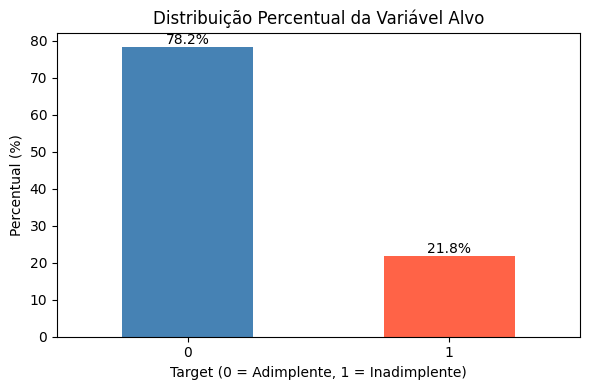

In [180]:
# Verificação do percentual de classes e desbalanceamento
percentual = df['target'].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(6, 4))
ax = percentual.plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Distribuição Percentual da Variável Alvo')
plt.xlabel('Target (0 = Adimplente, 1 = Inadimplente)')
plt.ylabel('Percentual (%)')
plt.xticks(rotation=0)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()


Observa-se um desbalanceamento moderado entre as classes, com predominância de clientes adimplentes (classe 0). Esse cenário é considerado na modelagem através de: (i) métricas menos sensíveis ao desbalanceamento (F1, ROC-AUC, KS, PR-AUC, não observando apenas a acurácia de forma isolada); e (ii) uso do parâmetro `class_weight="balanced"` (Regressão Logística/Random Forest) e `scale_pos_weight` (XGBoost/LightGBM) para penalizar mais os erros na classe minoritária durante o treinamento.

#### 3.2.3 Distribuição das variáveis

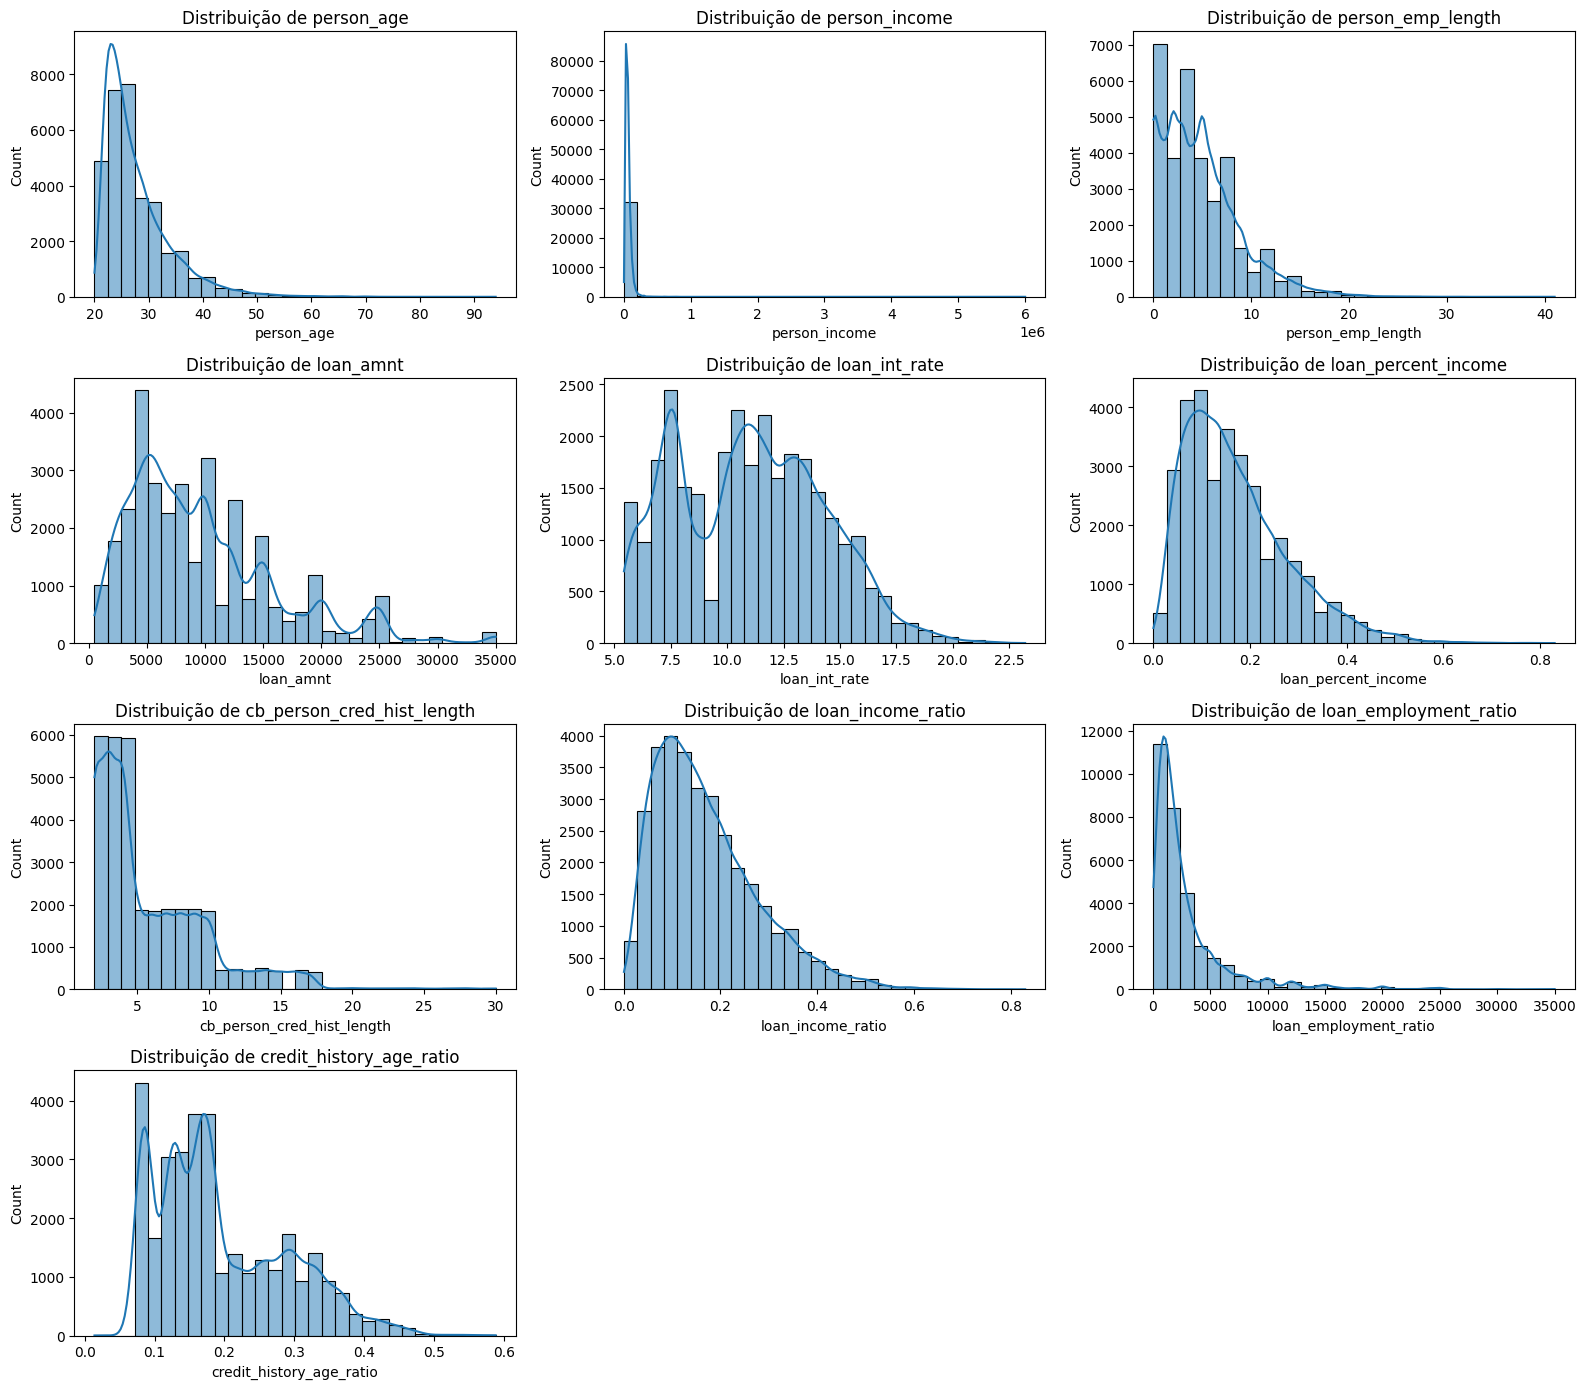

In [181]:
num_cols_eda = [
    'person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate',
    'loan_percent_income', 'cb_person_cred_hist_length',
    'loan_income_ratio', 'loan_employment_ratio', 'credit_history_age_ratio'
]

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()
for i, col in enumerate(num_cols_eda):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribuição de {col}')
for j in range(len(num_cols_eda), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


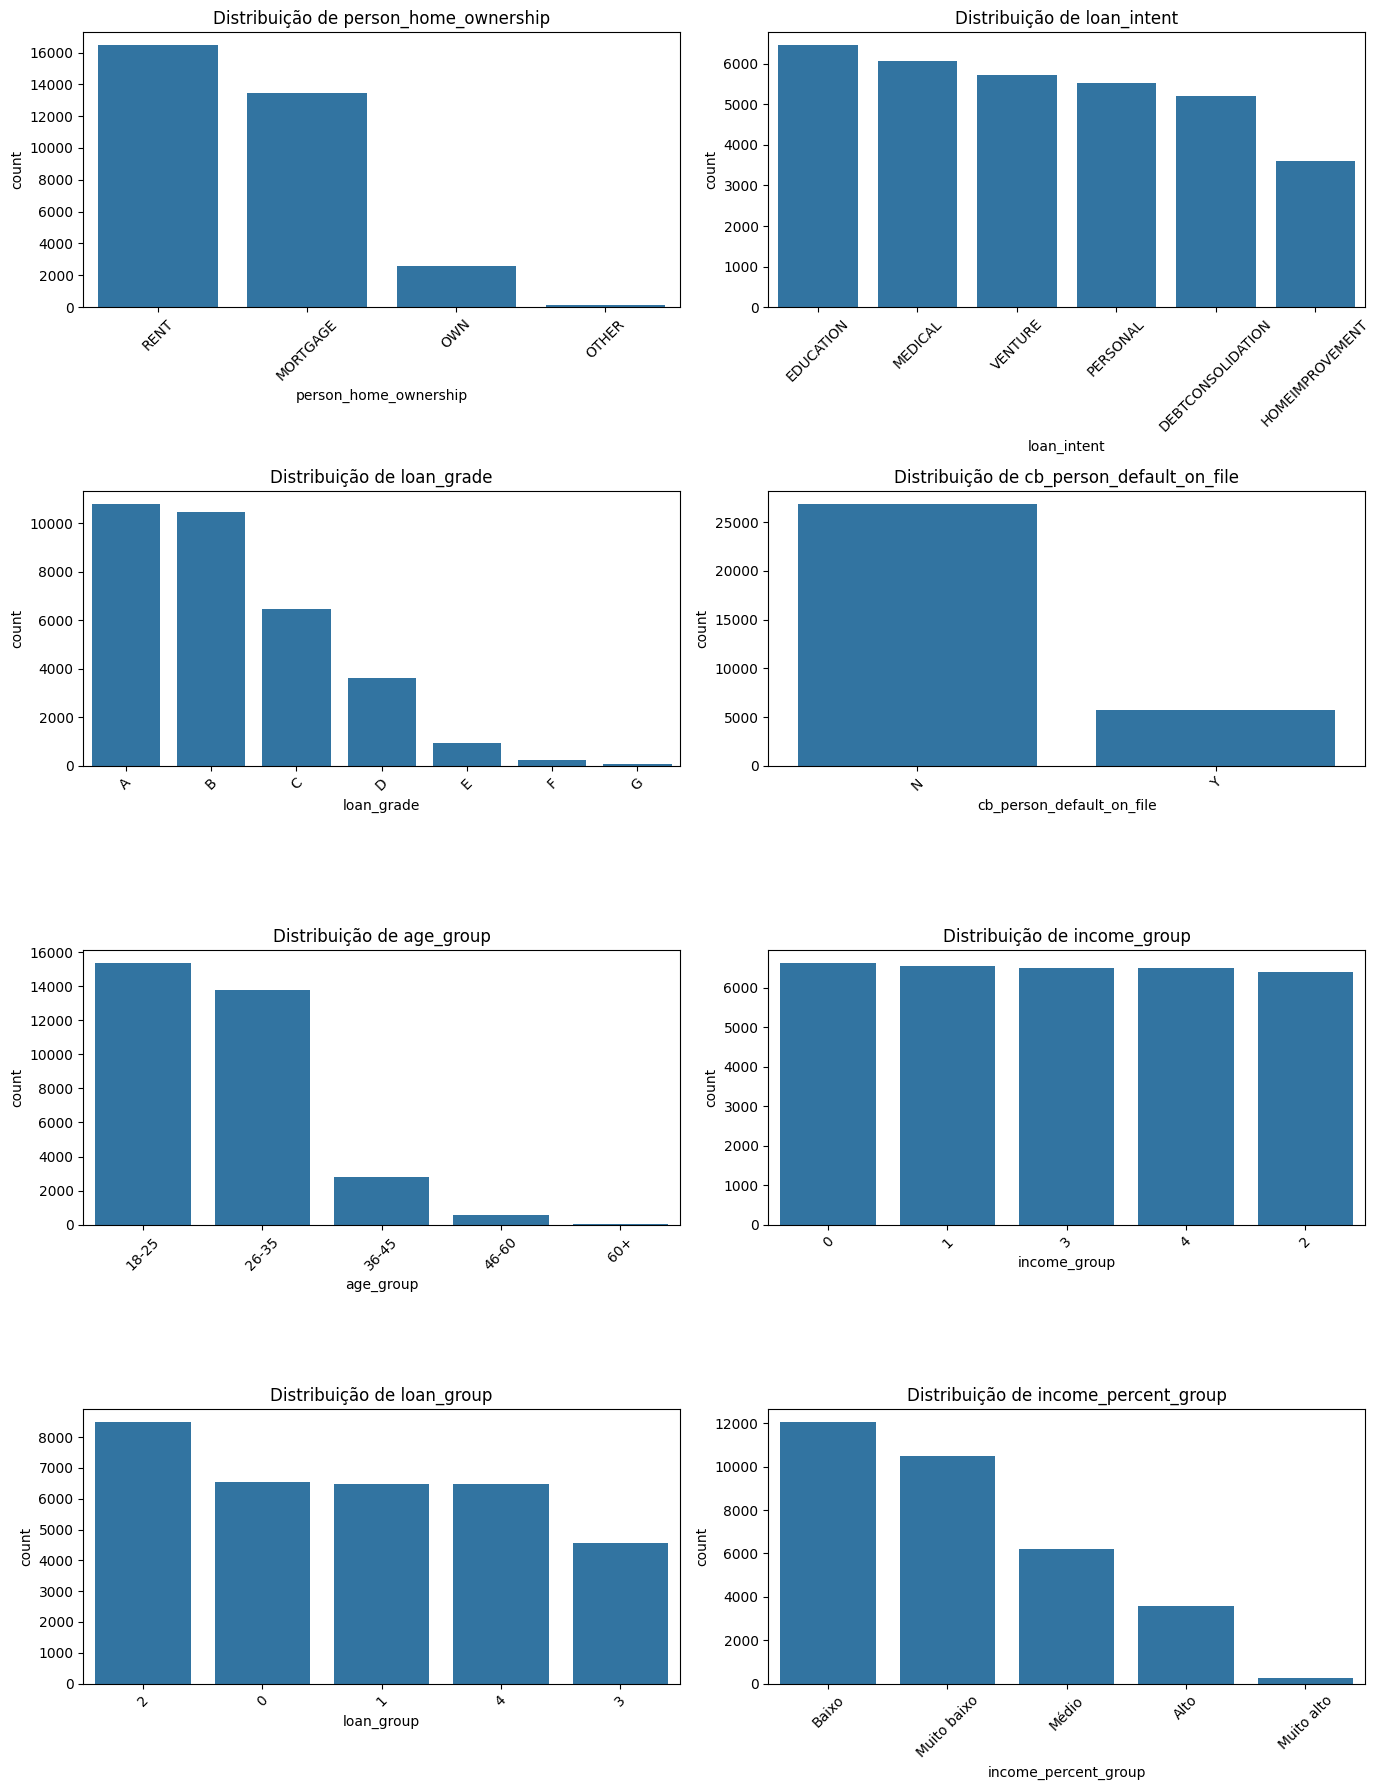

In [182]:
cat_cols_eda = [
    'person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file',
    'age_group', 'income_group', 'loan_group', 'income_percent_group'
]

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()
for i, col in enumerate(cat_cols_eda):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=axes[i])
    axes[i].set_title(f'Distribuição de {col}')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


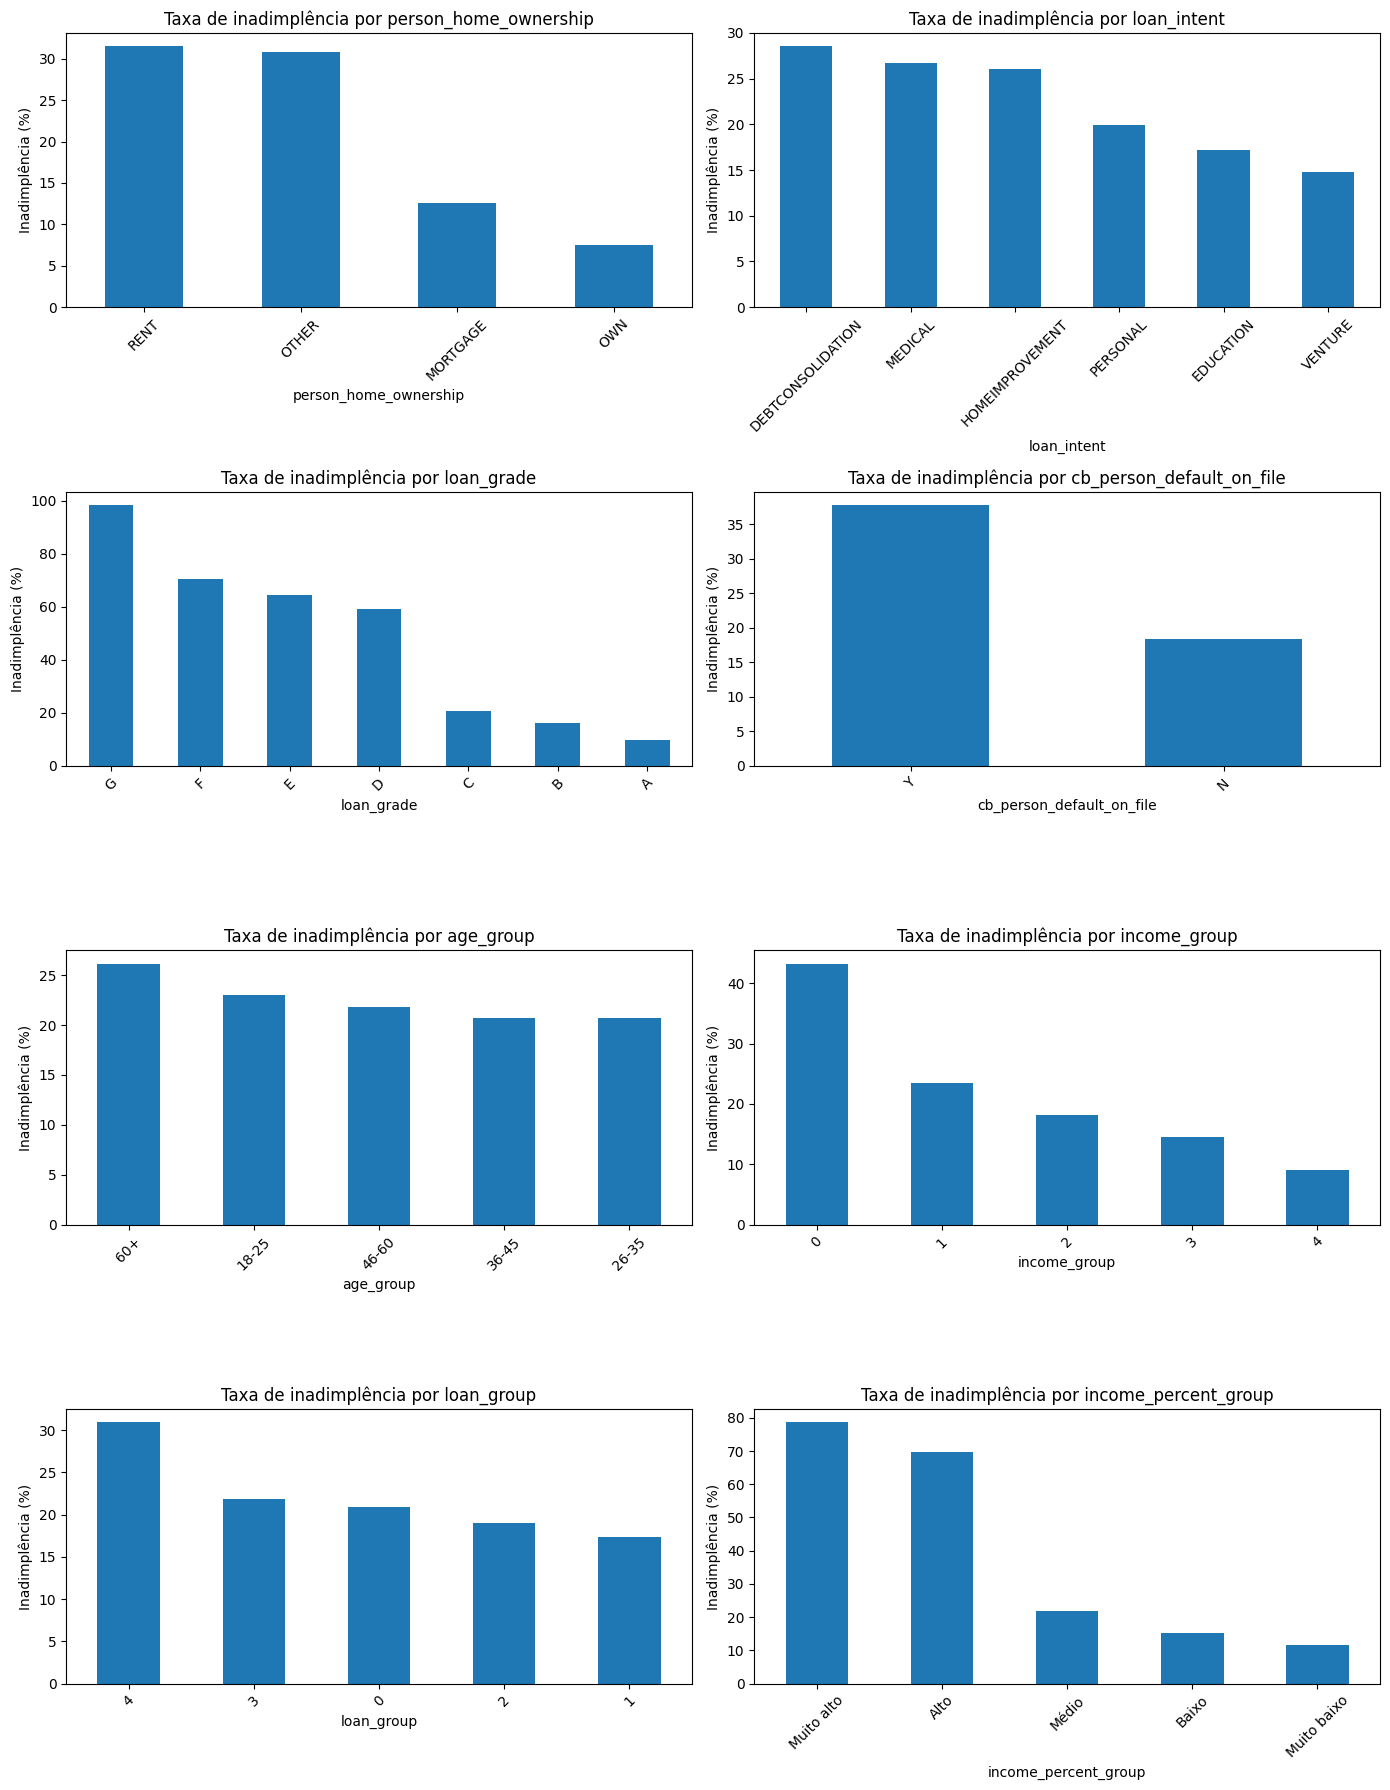

In [183]:
# Taxa de inadimplência por categoria
fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()
for i, col in enumerate(cat_cols_eda):
    default_rate = df.groupby(col)['target'].mean().sort_values(ascending=False) * 100
    default_rate.plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Taxa de inadimplência por {col}')
    axes[i].set_ylabel('Inadimplência (%)')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


#### 3.2.4 Principais insights

Com base nas análises acima:

- Clientes com maior percentual da renda comprometido (`loan_percent_income`) tendem a apresentar maior taxa de inadimplência.
- Empréstimos com taxas de juros mais elevadas (`loan_int_rate`) concentram maior proporção de inadimplentes, coerente com o mercado precificando risco previamente.
- Clientes com histórico anterior de inadimplência (`cb_person_default_on_file = Y`) apresentam risco significativamente maior.
- Determinadas finalidades de empréstimo (`loan_intent`) possuem taxas de inadimplência superiores às demais.
- A classificação de risco do empréstimo (`loan_grade`) apresenta relação monotônica com a inadimplência (quanto pior o grade, maior a taxa).

#### 3.2.5 Correlação e multicolinearidade

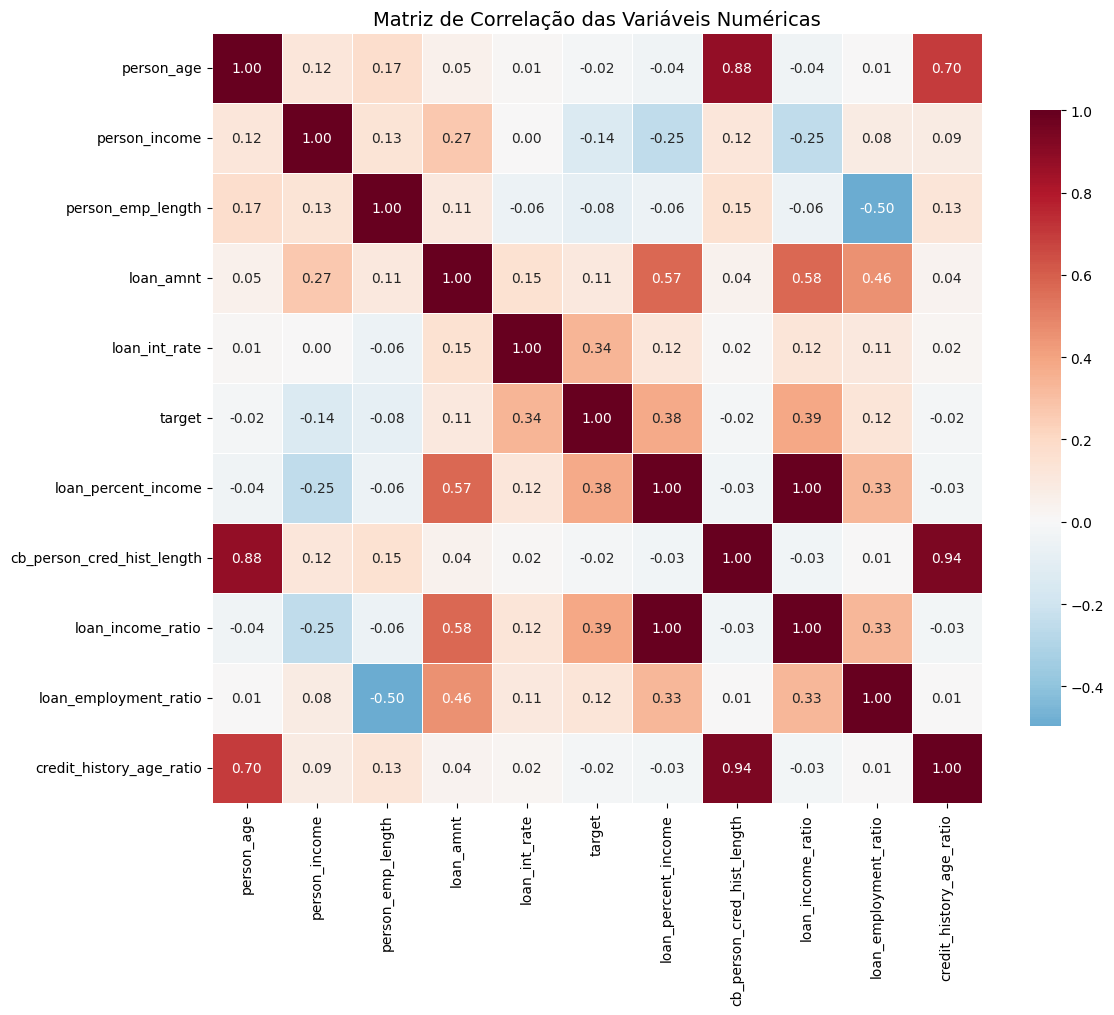

In [184]:
corr = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, linewidths=0.5,
            square=True, cbar_kws={"shrink": 0.8})
plt.title("Matriz de Correlação das Variáveis Numéricas", fontsize=14)
plt.tight_layout()
plt.show()


In [185]:
# Estratégia de redução de multicolinearidade:
# para pares de variáveis com |correlação| > 0.9, mantém-se a que possui maior correlação com o target
corr_matrix = df.select_dtypes(include=np.number).corr().abs()
corr_target = corr_matrix['target']

cols_to_drop = set()
comparacoes = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        col1, col2 = corr_matrix.columns[i], corr_matrix.columns[j]
        if col1 == 'target' or col2 == 'target':
            continue
        if corr_matrix.iloc[i, j] > 0.90:
            manter, remover = (col1, col2) if corr_target[col1] >= corr_target[col2] else (col2, col1)
            cols_to_drop.add(remover)
            comparacoes.append({"Var1": col1, "Var2": col2, "Corr": corr_matrix.iloc[i, j],
                                 "Manter": manter, "Remover": remover})

comparacoes = pd.DataFrame(comparacoes)
comparacoes


,Var1,Var2,Corr,Manter,Remover
0,loan_income_ratio,loan_percent_income,0.998942,loan_income_ratio,loan_percent_income
1,credit_history_age_ratio,cb_person_cred_hist_length,0.938472,credit_history_age_ratio,cb_person_cred_hist_length


In [186]:
df = df.drop(columns=cols_to_drop)
print("Colunas removidas por alta multicolinearidade:", cols_to_drop)


Colunas removidas por alta multicolinearidade: {'cb_person_cred_hist_length', 'loan_percent_income'}


Foi aplicada uma estratégia de redução de multicolinearidade baseada na matriz de correlação de Pearson. Variáveis com correlação absoluta superior a 0,9 foram avaliadas em pares, e aquelas com menor correlação com a variável alvo foram removidas.

Essa decisão visa reduzir redundância informacional e garantir maior estabilidade dos modelos, especialmente da Regressão Logística, que é sensível à multicolinearidade (coeficientes instáveis). Modelos em árvore são, em geral, mais robustos a esse problema, mas a remoção mantém a comparação justa entre os tipos modelo.


## 4 Definição de features e divisão dos dados

O conjunto de *features* de modelagem inclui tanto as variáveis originais/derivadas contínuas quanto as faixas categóricas criadas na Seção 3.1.2 (`age_group`, `income_group`, `loan_group`, `income_percent_group`).

A divisão é feita **antes** de qualquer ajuste de transformação (imputação, encoding, escala), que será aprendido exclusivamente no treino e aplicado no teste através de um `Pipeline` (Seção 5), evitando vazamento de dados.

**Justificativa da divisão treino/teste (80/20, estratificada):**
- **Proporção 80/20:** com aproximadamente 32,5 mil registros, uma reserva de 20% para teste (~6,5 mil registros) é suficiente para estimar as métricas de avaliação com baixa variância, mantendo a maior parte dos dados (80%) disponível para o treino e para a validação cruzada.
- **Estratificação (`stratify=y`):** a variável-alvo é desbalanceada (~22% de inadimplentes, Seção 3.2.2). Sem estratificar, uma divisão aleatória poderia, por acaso, concentrar mais ou menos inadimplentes no teste do que no treino, distorcendo a comparação de métricas sensíveis à proporção de classes (Recall, F1, KS). A estratificação garante que treino e teste preservem a mesma taxa de inadimplência, tornando a avaliação mais confiável e comparável entre os modelos.
- **`random_state=SEED` fixo:** garante que a mesma divisão seja reproduzida em qualquer reexecução do notebook, requisito básico de reprodutibilidade científica (Seção 2).


In [187]:
# Selecione o tipo de problema: 'classificacao' | 'regressao' | 'clusterizacao' | 'serie_temporal'
PROBLEM_TYPE = "classificacao"  # TODO: ajuste

# Defina features e target conforme o problema
if PROBLEM_TYPE == "classificacao":
    target = "target"
    features = [c for c in df.columns if c not in [target, "timestamp"]]
elif PROBLEM_TYPE == "regressao":
    target = "target_reg"
    features = [c for c in df.columns if c not in [target, "timestamp"]]
elif PROBLEM_TYPE == "clusterizacao":
    target = None
    features = [c for c in df.columns if c not in ["target","target_reg","timestamp"]]
elif PROBLEM_TYPE == "serie_temporal":
    target = "target_reg"  # Exemplo
    features = [c for c in df.columns if c not in [target]]
else:
    raise ValueError("PROBLEM_TYPE inválido.")

print("PROBLEM_TYPE:", PROBLEM_TYPE)
print("Target:", target)
print("N features:", len(features))

# Divisão dos dados
if PROBLEM_TYPE in ["classificacao", "regressao"]:
    X = df[features].copy()
    y = df[target].copy()
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y if PROBLEM_TYPE=="classificacao" else None
    )
    print("Treino:", X_train.shape, "| Teste:", X_test.shape)
    print("Taxa de inadimplência - treino:", round(y_train.mean() * 100, 2), "% | teste:", round(y_test.mean() * 100, 2), "%")
elif PROBLEM_TYPE == "clusterizacao":
    X = df[features].copy()
    # Sem target — você pode reservar um hold-out para avaliação externa se fizer sentido de negócio.
    X_train, X_test = train_test_split(X, test_size=0.2, random_state=SEED)
    print("Treino:", X_train.shape, "| Teste:", X_test.shape)
elif PROBLEM_TYPE == "serie_temporal":
    # Ordenar por tempo e criar cortes temporais (exemplo simples hold-out temporal)
    df_sorted = df.sort_values("timestamp")
    cutoff = int(len(df_sorted)*0.8)
    train, test = df_sorted.iloc[:cutoff], df_sorted.iloc[cutoff:]
    X_train, y_train = train.drop(columns=[target]), train[target]
    X_test, y_test   = test.drop(columns=[target]),  test[target]
    print("Treino:", X_train.shape, "| Teste:", X_test.shape)





PROBLEM_TYPE: classificacao
Target: target
N features: 16
Treino: (26064, 16) | Teste: (6517, 16)
Taxa de inadimplência - treino: 21.82 % | teste: 21.82 %



## 5 Pipeline de pré-processamento

O `ColumnTransformer` faz a imputação, escala (numéricas) e one-hot encoding (categóricas). Ele é encapsulado dentro do `Pipeline` de cada modelo, garantindo que o `fit` das transformações ocorra **apenas** no treino em cada *fold* de validação cruzada.
**Justificativa da estratégia de imputação:**
- **Numéricas → mediana:** a mediana é robusta a *outliers* e a distribuições assimétricas como se observa em `person_income` e `loan_amnt` (Seção 3.2.3), cuja cauda longa à direita faria a média ser puxada para cima por poucos valores extremos, gerando uma imputação enviesada. A mediana representa melhor o "valor típico" nesses casos.
- **Categóricas → moda (`most_frequent`):** para variáveis categóricas não há média/mediana bem definida; substituir pelo valor mais frequente é a abordagem padrão, e de menor viés, quando a ausência de dado é pontual e não parece seguir um padrão sistemático (o que foi verificado na Seção 3.2.1, poucos valores ausentes, sem concentração aparente em uma classe específica).
- **Por que não descartar os registros com ausência e sim, usar inputação?** como visto na Seção 3.2.1, a proporção de valores ausentes é baixa; ainda assim, descartar linhas jogaria fora informação válida das demais colunas daquele cliente (mesmo raciocínio aplicado ao tratamento dos valores incoerentes de idade/tempo de emprego, Seção 3.2.1), imputar preserva o tamanho da amostra sem introduzir viés relevante.
- **Por que a imputação está dentro do `Pipeline`, e não aplicada direto no `df`:** calcular mediana/moda usando o dataset inteiro (antes do split) vazaria informação do teste para o treino. No `Pipeline`, a mediana/moda é recalculada **usando apenas os dados de treino** em cada *fold* de validação cruzada, e depois aplicada ao teste/validação sem alterá-lo, a mesma lógica de prevenção de vazamento já adotada na divisão treino/teste (Seção 4).



In [188]:
num_cols = X_train.select_dtypes(include=["float64", "int64"]).columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
])

print("Variáveis numéricas:", num_cols)
print("Variáveis categóricas:", cat_cols)


Variáveis numéricas: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_income_ratio', 'loan_employment_ratio', 'credit_history_age_ratio']
Variáveis categóricas: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file', 'age_group', 'income_group', 'loan_group', 'income_percent_group']



## 6 Baseline e modelos candidatos

- **Baseline:** `DummyClassifier` (sempre prevê a classe majoritária).
- **Modelo tradicional:** Regressão Logística (`class_weight="balanced"`), o padrão de mercado por interpretabilidade.
- **Modelos em árvore:** Decision Tree, Random Forest, Gradient Boosting, XGBoost e LightGBM.

Para as árvores de gradient boosting, o desbalanceamento é tratado via `scale_pos_weight` (razão entre classe negativa e positiva no treino), equivalente ao `class_weight="balanced"` da regressão logística/random forest.


In [189]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight (classe 0 / classe 1):", round(scale_pos_weight, 2))

baseline = Pipeline([("pre", preprocess), ("model", DummyClassifier(strategy="most_frequent", random_state=SEED))])

candidates = {
    "LogisticRegression": Pipeline([
        ("pre", preprocess),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED))
    ]),
    "RandomForest": Pipeline([
        ("pre", preprocess),
        ("model", RandomForestClassifier(class_weight="balanced", random_state=SEED))
    ]),
    "GradientBoosting": Pipeline([
        ("pre", preprocess),
        ("model", GradientBoostingClassifier(random_state=SEED))
    ]),
    "XGBoost": Pipeline([
        ("pre", preprocess),
        ("model", XGBClassifier(
            scale_pos_weight=scale_pos_weight, eval_metric="logloss",
            random_state=SEED, n_jobs=-1
        ))
    ]),
    "LightGBM": Pipeline([
        ("pre", preprocess),
        ("model", LGBMClassifier(
            scale_pos_weight=scale_pos_weight, random_state=SEED, n_jobs=-1, verbose=-1
        ))
    ]),
}
list(candidates.keys())


scale_pos_weight (classe 0 / classe 1): 3.58


['LogisticRegression',
 'RandomForest',
 'GradientBoosting',
 'XGBoost',
 'LightGBM']

### 6.1 Treino e avaliação (baseline vs. candidatos)

In [190]:
results = {}

fit_and_evaluate("baseline", baseline, X_train, y_train, X_test, y_test, results)
for name, pipe in candidates.items():
    fit_and_evaluate(name, pipe, X_train, y_train, X_test, y_test, results)

results_df = pd.DataFrame(results).T.sort_values("ROC_AUC", ascending=False)
results_df


,Accuracy,Precision,Recall,F1,Specificity,ROC_AUC,PR_AUC,KS,train_time_s
XGBoost,0.922510,0.841400,0.794655,0.817360,0.958194,0.949432,0.906145,0.759370,0.711
LightGBM,0.919595,0.836582,0.784810,0.809869,0.957213,0.946390,0.900584,0.750280,0.485
RandomForest,0.931257,0.974659,0.703235,0.816993,0.994897,0.928265,0.880456,0.730851,4.173
GradientBoosting,0.927421,0.948064,0.706048,0.809351,0.989205,0.925308,0.872176,0.701889,8.278
LogisticRegression,0.833359,0.588143,0.788326,0.673678,0.845927,0.888075,0.752273,0.647162,1.157
baseline,0.781801,0.000000,0.000000,0.000000,1.000000,0.500000,0.218199,0.000000,0.229


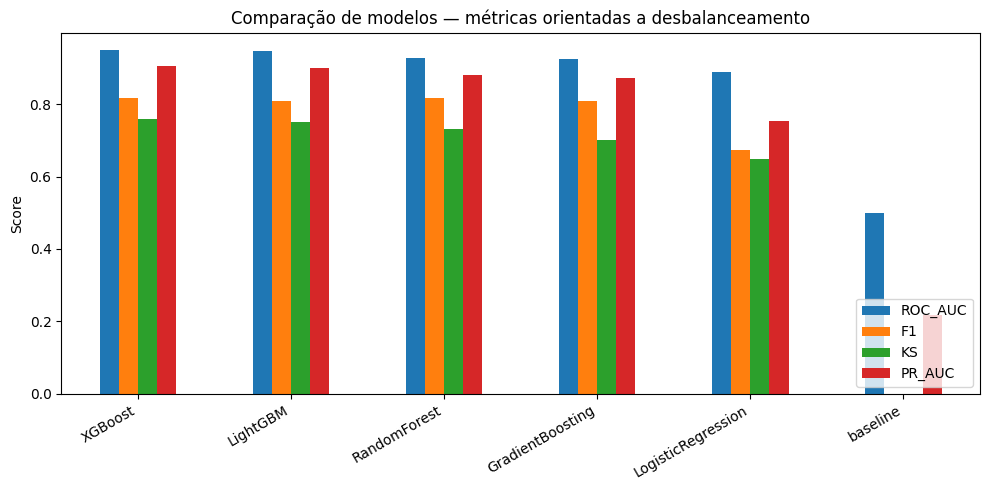

In [191]:
results_df[["ROC_AUC", "F1", "KS", "PR_AUC"]].plot(kind="bar", figsize=(10, 5))
plt.title("Comparação de modelos — métricas orientadas a desbalanceamento")
plt.ylabel("Score")
plt.xticks(rotation=30, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


**Interpretação dos resultados:** em problemas de crédito, `ROC_AUC` e `KS` são as métricas de referência no mercado para separabilidade de risco, enquanto `F1`/`Recall` importam para a decisão de corte (Seção 8). Os modelos em árvore, e em particular os gradient boosting (XGBoost/LightGBM), tendem a superar a Regressão Logística por capturarem relações não lineares e interações entre variáveis (ex.: `loan_percent_income` × `loan_grade`) que um modelo linear não representa diretamente sem *feature engineering* manual.

### 6.2 Comparação: contínuas vs. faixas categóricas vs. ambas

As faixas categóricas (`age_group`, `income_group`, `loan_group`, `income_percent_group`) são derivadas das variáveis contínuas `person_age`, `person_income`, `loan_amnt` e `loan_percent_income`, respectivamente. Usá-las **junto** com as contínuas (como nas Seções 6/7/8) mistura o efeito de duas fontes de informação parcialmente redundantes, dificultando isolar se a faixa realmente ajuda ou se o modelo apenas reaproveita informação que já tinha.

Para isolar esse efeito, comparam-se três cenários de *features*,usando os dois modelos protagonistas do MVP, a Regressão Logística e o melhor modelo em árvore escolhido XGBoost, com hiperparâmetros-padrão (sem tuning, para manter o experimento rápido e focado apenas no efeito das *features*):

 1. **Só contínuas:** `person_age`, `person_income`, `loan_amnt` no lugar de suas faixas + demais variáveis.
 2. **Só faixas:** `age_group`, `income_group`, `loan_group`, `income_percent_group` no lugar das contínuas correspondentes + demais variáveis.
 3. **Ambas (atual):** as contínuas e as faixas juntas, o que já vinha sendo usado até aqui.

> **Obs.:** `income_percent_group` é derivada de `loan_percent_income`, que foi removida na Seção 3.2.5 por alta multicolinearidade com `loan_income_ratio` (ambas medem, em essência, o comprometimento de renda). Por isso não há uma versão "puramente contínua" equivalente a `income_percent_group` disponível no conjunto atual de *features*, o cenário "Só faixas" contempla essa informação (via a faixa), enquanto o cenário "Só contínuas" fica sem ela. As demais variáveis (`person_emp_length`, `loan_int_rate`, as razões derivadas e as categóricas originais) permanecem iguais nos três cenários, pois não têm par contínua/faixa.


In [192]:

best_name = results_df.drop(index="baseline").index[0]  # melhor candidato da Seção 6.1

bin_cols = ['age_group', 'income_group', 'loan_group', 'income_percent_group']
bin_source_cols = ['person_age', 'person_income', 'loan_amnt']  # loan_percent_income já foi removida (Seção 3.2.5)
other_cols = [c for c in features if c not in bin_cols + bin_source_cols]

feature_sets = {
    "Só contínuas": other_cols + bin_source_cols,
    "Só faixas": other_cols + bin_cols,
    "Ambas (atual)": other_cols + bin_source_cols + bin_cols,
}

def build_pipeline(model, cols):
    num = [c for c in cols if X_train[c].dtype.kind in "if"]
    cat = [c for c in cols if c not in num]
    pre = ColumnTransformer([("num", numeric_pipe, num), ("cat", categorical_pipe, cat)])
    return Pipeline([("pre", pre), ("model", model)])

models_for_ablation = {
    "LogisticRegression": candidates["LogisticRegression"].named_steps["model"],
    best_name: candidates[best_name].named_steps["model"],
}

ablation_results = {}
for set_name, cols in feature_sets.items():
    print(f"Cenário '{set_name}': {len(cols)} features")
    for model_name, model in models_for_ablation.items():
        pipe = build_pipeline(clone(model), cols)
        key = f"{model_name} | {set_name}"
        fit_and_evaluate(key, pipe, X_train[cols], y_train, X_test[cols], y_test, ablation_results)

ablation_df = pd.DataFrame(ablation_results).T[["ROC_AUC","Recall", "F1", "KS"]]
ablation_df


Cenário 'Só contínuas': 12 features
Cenário 'Só faixas': 13 features
Cenário 'Ambas (atual)': 16 features


,ROC_AUC,Recall,F1,KS
LogisticRegression | Só contínuas,0.873678,0.781294,0.650468,0.613369
XGBoost | Só contínuas,0.948697,0.790436,0.814788,0.753534
LogisticRegression | Só faixas,0.887362,0.790436,0.671847,0.645117
XGBoost | Só faixas,0.926543,0.752461,0.787054,0.711426
LogisticRegression | Ambas (atual),0.888075,0.788326,0.673678,0.647162
XGBoost | Ambas (atual),0.949446,0.794655,0.817360,0.759566


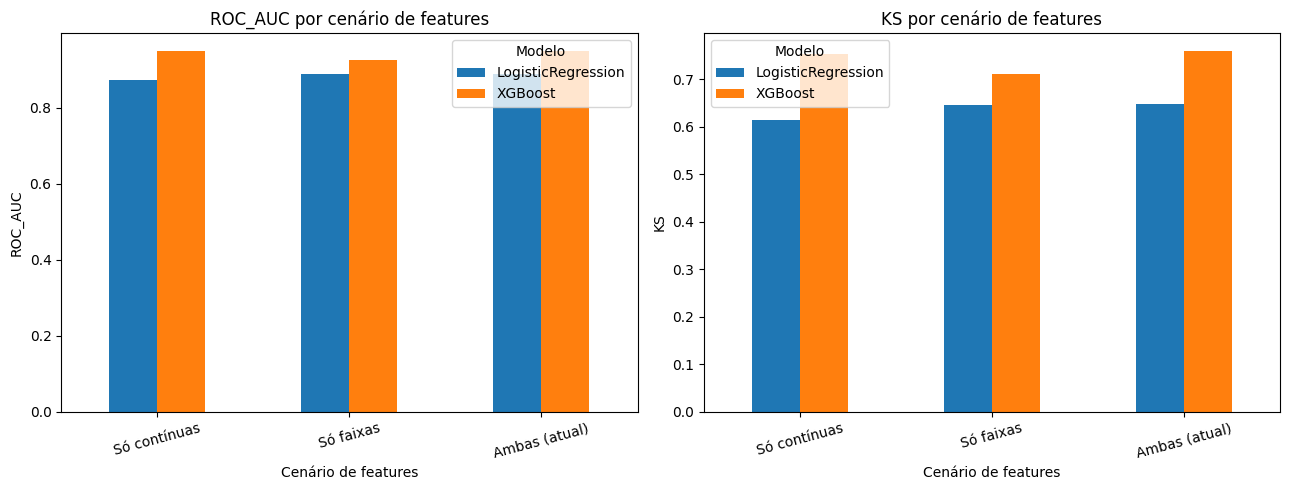

In [193]:
plot_df = ablation_df.reset_index().rename(columns={"index": "config"})
plot_df["Modelo"] = plot_df["config"].apply(lambda x: x.split(" | ")[0])
plot_df["Cenário de features"] = plot_df["config"].apply(lambda x: x.split(" | ")[1])

ordem = ["Só contínuas", "Só faixas", "Ambas (atual)"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for metric, ax in zip(["ROC_AUC", "KS"], axes):
    pivot = plot_df.pivot(index="Cenário de features", columns="Modelo", values=metric).loc[ordem]
    pivot.plot(kind="bar", ax=ax)
    ax.set_title(f"{metric} por cenário de features")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()


**Interpretação dos resultados:** A Regressão Logística tem um ganho ROC-AUC/KS ao trocar as contínuas pelas faixas, porque a discretização entrega uma forma de não linearidade que o modelo linear não capturaria sozinho, enquanto o modelo em árvore XGBoost tem uma melhor performance com apenas as variáveis continúas, já que ele encontra pontos de corte mais eficientes que os quintis do `qcut` diretamente a partir das variáveis contínuas. O cenário "Ambas" tende a ser o melhor ou muito próximo para os dois modelos, mas por motivos opostos: para a Regressão Logística, porque preserva o ganho trazido pela discretização; para o XGBoost, porque o modelo simplesmente ignora a redundância das faixas e se apoia nas contínuas, que já bastam. Esse é o argumento prático mais forte a favor do uso de árvores neste MVP: elas entregam o teto de performance sem exigir a etapa manual e arbitrária de engenharia de faixas que um modelo tradicional como a Regressão Logística.


## 7 Validação cruzada e otimização de hiperparâmetros

O melhor candidato da Seção 6 é otimizado via `RandomizedSearchCV` com `StratifiedKFold` (preserva a proporção de classes em cada *fold*), otimizando `roc_auc`. A Regressão Logística também é ajustada, para manter uma comparação justa entre a "melhor versão possível" de cada família de modelo (tradicional vs. árvore).


In [194]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

best_name = results_df.drop(index="baseline").index[0]
print("Melhor candidato na Seção 6:", best_name)

param_grids = {
    "XGBoost": {
        "model__n_estimators": randint(150, 500),
        "model__max_depth": randint(3, 10),
        "model__learning_rate": uniform(0.01, 0.29),
        "model__subsample": uniform(0.6, 0.4),
        "model__colsample_bytree": uniform(0.6, 0.4),
    },
    "LightGBM": {
        "model__n_estimators": randint(150, 500),
        "model__max_depth": randint(3, 12),
        "model__learning_rate": uniform(0.01, 0.29),
        "model__num_leaves": randint(15, 100),
        "model__subsample": uniform(0.6, 0.4),
    },
    "RandomForest": {
        "model__n_estimators": randint(150, 500),
        "model__max_depth": randint(3, 20),
        "model__min_samples_split": randint(2, 10),
    },
    "GradientBoosting": {
        "model__n_estimators": randint(100, 400),
        "model__max_depth": randint(2, 8),
        "model__learning_rate": uniform(0.01, 0.29),
    },
    "LogisticRegression": {
        "model__C": uniform(0.01, 10),
        "model__penalty": ["l2"],
    },
}

search_tree = RandomizedSearchCV(
    candidates[best_name], param_distributions=param_grids[best_name],
    n_iter=25, cv=cv, scoring="roc_auc", random_state=SEED, n_jobs=-1, verbose=0
)
search_tree.fit(X_train, y_train)
print(f"[{best_name}] Melhor ROC-AUC (CV):", round(search_tree.best_score_, 4))
print(f"[{best_name}] Melhores parâmetros:", search_tree.best_params_)

search_lr = RandomizedSearchCV(
    candidates["LogisticRegression"], param_distributions=param_grids["LogisticRegression"],
    n_iter=15, cv=cv, scoring="roc_auc", random_state=SEED, n_jobs=-1, verbose=0
)
search_lr.fit(X_train, y_train)
print("\n[LogisticRegression] Melhor ROC-AUC (CV):", round(search_lr.best_score_, 4))
print("[LogisticRegression] Melhores parâmetros:", search_lr.best_params_)


Melhor candidato na Seção 6: XGBoost
[XGBoost] Melhor ROC-AUC (CV): 0.946
[XGBoost] Melhores parâmetros: {'model__colsample_bytree': np.float64(0.7799016533479063), 'model__learning_rate': np.float64(0.12459356844052617), 'model__max_depth': 6, 'model__n_estimators': 419, 'model__subsample': np.float64(0.8909087983425683)}

[LogisticRegression] Melhor ROC-AUC (CV): 0.889
[LogisticRegression] Melhores parâmetros: {'model__C': np.float64(0.5908361216819946), 'model__penalty': 'l2'}



##8 Avaliação final, análise de erros e limitações

Comparação, no conjunto de teste, entre o melhor modelo tradicional (Regressão Logística ajustada) e o melhor modelo em árvore ajustado.

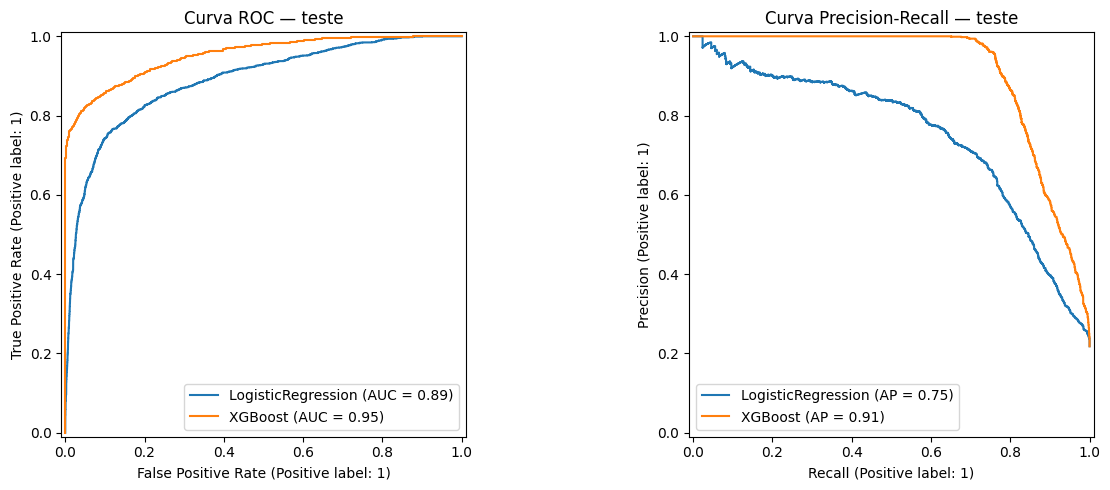

In [195]:
best_tree = search_tree.best_estimator_
best_lr = search_lr.best_estimator_

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
RocCurveDisplay.from_estimator(best_lr, X_test, y_test, ax=axes[0], name="LogisticRegression")
RocCurveDisplay.from_estimator(best_tree, X_test, y_test, ax=axes[0], name=best_name)
axes[0].set_title("Curva ROC — teste")

PrecisionRecallDisplay.from_estimator(best_lr, X_test, y_test, ax=axes[1], name="LogisticRegression")
PrecisionRecallDisplay.from_estimator(best_tree, X_test, y_test, ax=axes[1], name=best_name)
axes[1].set_title("Curva Precision-Recall — teste")
plt.tight_layout()
plt.show()


**Interpretação dos Resultados**:
1. Curva ROC (esquerda): A Curva ROC avalia a capacidade do modelo de diferenciar clientes adimplentes de inadimplentes considerando todos os possíveis limiares de decisão. Quanto maior a área sob a curva (AUC), melhor é o desempenho do modelo.
Observa-se que o XGBoost apresentou AUC de 0.95, superior à Regressão Logística (AUC = 0.89). Isso indica que o XGBoost possui maior capacidade de distinguir corretamente clientes com maior risco de inadimplência.
2. Curva Precision-Recall (direita):
A Curva Precision-Recall é particularmente importante em problemas de classificação desbalanceados, como este, em que a classe de interesse (clientes inadimplentes) representa uma parcela menor da base de dados.
O XGBoost obteve Average Precision (AP) de 0.91, enquanto a Regressão Logística apresentou AP de 0.75. Esse resultado demonstra que o XGBoost mantém melhor equilíbrio entre Precisão (proporção de clientes classificados como inadimplentes que realmente são inadimplentes) e Recall (capacidade de identificar os clientes inadimplentes).

===== LogisticRegression (ajustada) =====
              precision    recall  f1-score   support

  Adimplente       0.93      0.85      0.89      5095
Inadimplente       0.59      0.79      0.67      1422

    accuracy                           0.83      6517
   macro avg       0.76      0.82      0.78      6517
weighted avg       0.86      0.83      0.84      6517

===== XGBoost (ajustado) =====
              precision    recall  f1-score   support

  Adimplente       0.94      0.97      0.96      5095
Inadimplente       0.88      0.79      0.83      1422

    accuracy                           0.93      6517
   macro avg       0.91      0.88      0.89      6517
weighted avg       0.93      0.93      0.93      6517



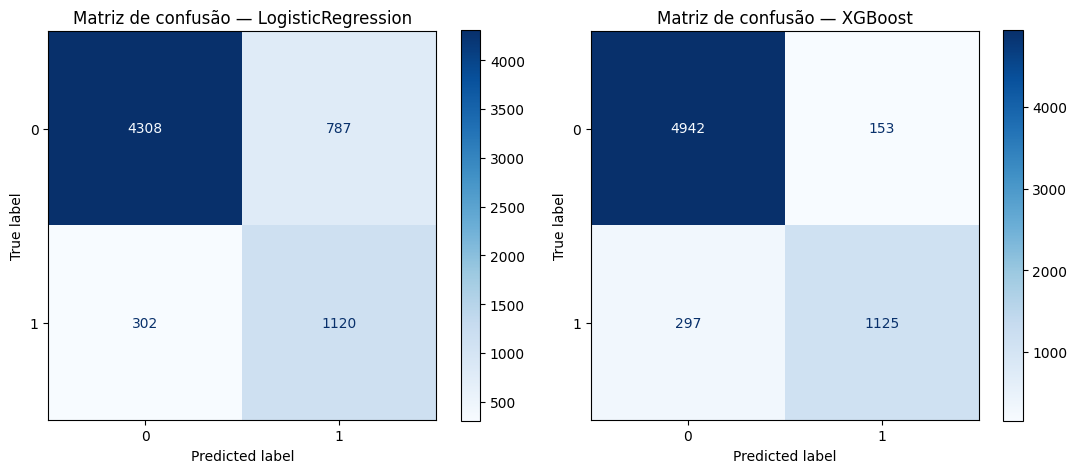

In [196]:
for name, model in [("LogisticRegression (ajustada)", best_lr), (f"{best_name} (ajustado)", best_tree)]:
    y_pred = model.predict(X_test)
    print(f"===== {name} =====")
    print(classification_report(y_test, y_pred, target_names=["Adimplente", "Inadimplente"]))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay.from_estimator(best_lr, X_test, y_test, ax=axes[0], cmap="Blues")
axes[0].set_title("Matriz de confusão — LogisticRegression")
ConfusionMatrixDisplay.from_estimator(best_tree, X_test, y_test, ax=axes[1], cmap="Blues")
axes[1].set_title(f"Matriz de confusão — {best_name}")
plt.tight_layout()
plt.show()


**Interpretação dos Resultados:**  A Regressão Logística apresentou acurácia de 83%, enquanto o XGBoost alcançou 93%, indicando melhor desempenho geral. Como o problema apresenta desbalanceamento entre as classes, a análise das métricas da classe Inadimplente é mais relevante. Ambos os modelos obtiveram Recall de 0.79, identificando aproximadamente 79% dos clientes inadimplentes. No entanto, o XGBoost apresentou Precisão superior (0.88 contra 0.59) e F1-score mais elevado (0.83 contra 0.67), reduzindo significativamente a ocorrência de falsos positivos. Esses resultados indicam que o XGBoost mantém a capacidade de identificar clientes de risco, ao mesmo tempo em que reduz a classificação incorreta de bons pagadores como inadimplentes, tornando-o mais adequado para aplicações de concessão de crédito.

### 8.1 Overfitting vs. underfitting

Além do desempenho no teste, é importante checar se os modelos estão **memorizando** o treino (*overfitting* bom no treino, ruim no teste) ou **não aprendendo o suficiente** (*underfitting*  ruim em ambos). Isso é feito comparando a mesma métrica calculada no treino e no teste: uma diferença grande (treino ≫ teste) indica overfitting; um desempenho baixo nos dois indica underfitting; valores próximos e altos indicam um bom ajuste, generalizando bem.

In [197]:
overfit_check = {}
for name, model in [("LogisticRegression (ajustada)", best_lr), (f"{best_name} (ajustado)", best_tree)]:
    proba_train = model.predict_proba(X_train)[:, 1]
    proba_test_ = model.predict_proba(X_test)[:, 1]

    roc_train = roc_auc_score(y_train, proba_train)
    roc_test = roc_auc_score(y_test, proba_test_)

    f1_train = f1_score(y_train, model.predict(X_train))
    f1_test = f1_score(y_test, model.predict(X_test))

    ks_train = ks_2samp(proba_train[y_train == 0], proba_train[y_train == 1]).statistic
    ks_test = ks_2samp(proba_test_[y_test == 0], proba_test_[y_test == 1]).statistic

    overfit_check[name] = {
        "ROC_AUC_treino": roc_train, "ROC_AUC_teste": roc_test, "gap_ROC_AUC": roc_train - roc_test,
        "F1_treino": f1_train, "F1_teste": f1_test, "gap_F1": f1_train - f1_test,
        "KS_treino": ks_train, "KS_teste": ks_test, "gap_KS": ks_train - ks_test,
    }

overfit_df = pd.DataFrame(overfit_check).T
overfit_df

,ROC_AUC_treino,ROC_AUC_teste,gap_ROC_AUC,F1_treino,F1_teste,gap_F1,KS_treino,KS_teste,gap_KS
LogisticRegression (ajustada),0.890335,0.888077,0.002258,0.679009,0.672875,0.006134,0.645339,0.646769,-0.001430
XGBoost (ajustado),0.999689,0.952576,0.047113,0.984010,0.833333,0.150677,0.986459,0.771690,0.214769


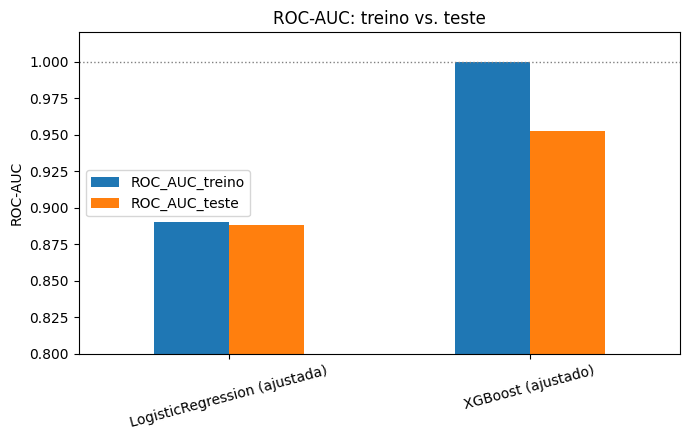

In [198]:
overfit_df[["ROC_AUC_treino", "ROC_AUC_teste"]].plot(kind="bar", figsize=(7, 4.5))
plt.title("ROC-AUC: treino vs. teste")
plt.ylabel("ROC-AUC")
plt.ylim(0.8, 1.02)
plt.xticks(rotation=15)
plt.axhline(1.0, color="gray", linestyle=":", linewidth=1)
plt.tight_layout()
plt.show()

**Interpretação dos resultados:** Embora o XGBoost tenha apresentado desempenho superior ao da Regressão Logística no conjunto de teste, observou-se um aumento do gap entre as métricas de treinamento e teste, indicando um grau moderado de sobreajuste (overfitting). Ainda assim, o modelo manteve elevada capacidade de generalização, superando a Regressão Logística em todas as métricas avaliadas. Considerando que o objetivo deste MVP é comparar o desempenho e a interpretabilidade de diferentes algoritmos de classificação, optou-se por não realizar novos ajustes no XGBoost nesta etapa. Como trabalho futuro, pretende-se investigar estratégias adicionais de regularização e otimização de hiperparâmetros, visando reduzir o sobreajuste sem comprometer o desempenho preditivo.

### 8.2 Análise de sensibilidade ao ponto de corte (threshold)

O limiar padrão de 0.5 raramente é o ideal em crédito: o custo de negar crédito a um bom pagador (Falso Positivo) é diferente do custo de aprovar um mau pagador (Falso Negativo). A curva abaixo mostra como Precision e Recall variam conforme o corte, apoiando a escolha de negócio (não estatística) do ponto de operação.

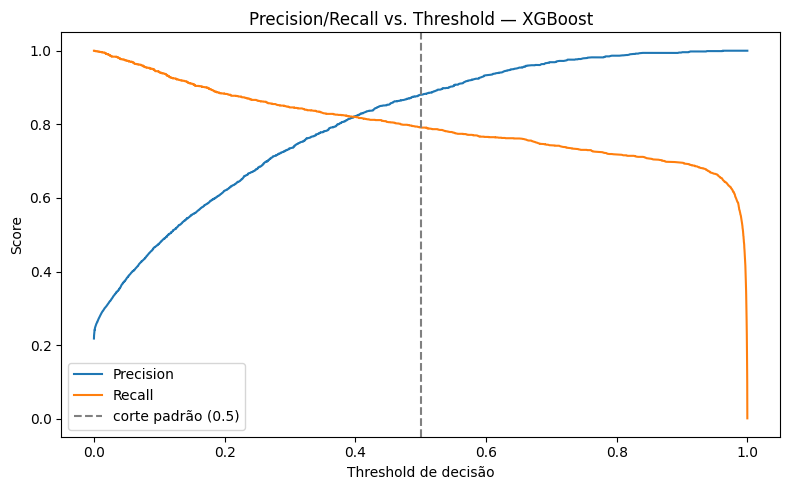

In [199]:
from sklearn.metrics import precision_recall_curve

proba_tree = best_tree.predict_proba(X_test)[:, 1]
prec, rec, thr = precision_recall_curve(y_test, proba_tree)

plt.figure(figsize=(8, 5))
plt.plot(thr, prec[:-1], label="Precision")
plt.plot(thr, rec[:-1], label="Recall")
plt.axvline(0.5, color="gray", linestyle="--", label="corte padrão (0.5)")
plt.xlabel("Threshold de decisão")
plt.ylabel("Score")
plt.title(f"Precision/Recall vs. Threshold — {best_name}")
plt.legend()
plt.tight_layout()
plt.show()


**Limitações do estudo:**
- O dataset é uma amostra estática e pública; não há garantia de que reflita a carteira/safra atual de uma instituição real, nem captura *drift* de risco ao longo do tempo (ex.: ciclos econômicos).
- Não há chave de cliente única, o que impede tratar corretamente eventuais duplicidades e checar vazamento de cliente entre treino/teste.
- Não há coluna de safra (data de concessão), com isso não foi possível fazer análises temporais de estabilidade das métricas.
- A otimização de hiperparâmetros usa `RandomizedSearchCV` (busca amostrada, não exaustiva) por custo computacional, uma busca mais ampla (ex.: Bayesian Optimization/Optuna) poderia extrair um ganho marginal adicional.



## 9 Explicabilidade (XAI) via SHAP

Esta é a seção central do MVP: usar **SHAP (SHapley Additive exPlanations)** para abrir a "caixa-preta" do melhor modelo em árvore, extraindo:

- **Explicabilidade global:** quais variáveis mais influenciam as decisões do modelo no agregado (equivalente, aos coeficientes de uma Regressão Logística).
- **Explicabilidade local:** por que o modelo tomou uma decisão específica para um cliente individual (essencial para justificar uma negativa de crédito).

Como `best_tree` é um modelo em árvore, usamos o `TreeExplainer`, que é exato e eficiente para esse tipo de modelo.


In [200]:
# Extrai o modelo final e os dados já transformados pelo pipeline, para o SHAP interpretar
# as mesmas features que o modelo efetivamente utiliza
fitted_preprocess = best_tree.named_steps["pre"]
fitted_model = best_tree.named_steps["model"]

feature_names = fitted_preprocess.get_feature_names_out()
X_test_transformed = pd.DataFrame(
    fitted_preprocess.transform(X_test).toarray() if hasattr(fitted_preprocess.transform(X_test), "toarray")
    else fitted_preprocess.transform(X_test),
    columns=feature_names, index=X_test.index
)

explainer = shap.TreeExplainer(fitted_model)
shap_values = explainer(X_test_transformed)
print("Shape dos valores SHAP:", shap_values.values.shape)


Shape dos valores SHAP: (6517, 47)


### 9.1 Explicabilidade global

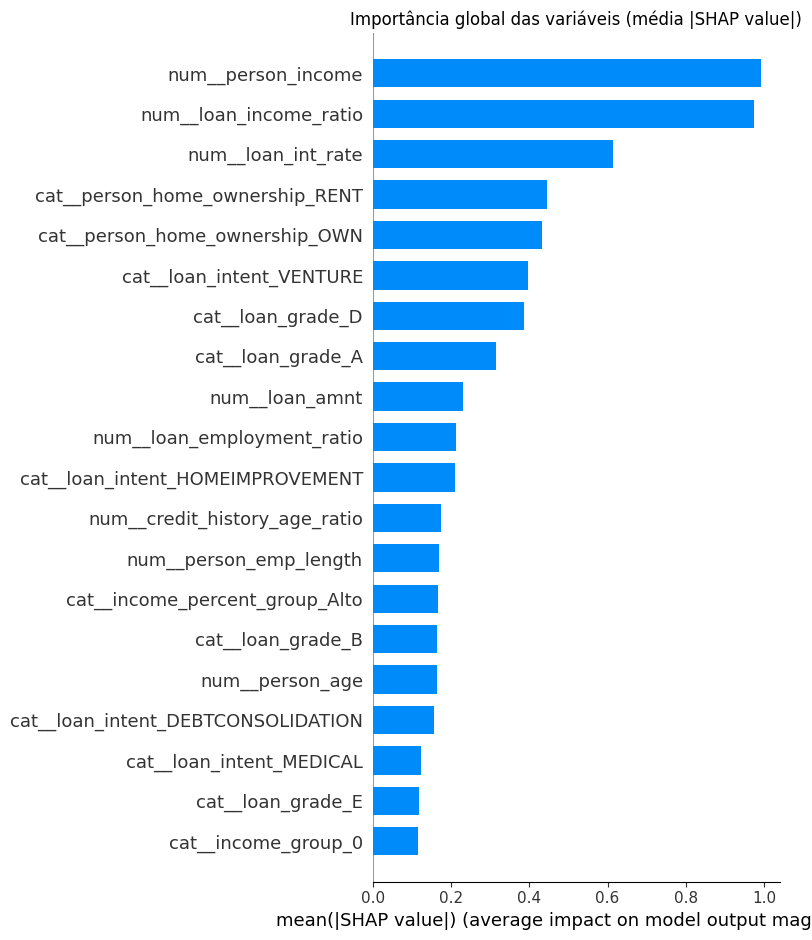

In [201]:
shap.summary_plot(shap_values, X_test_transformed, plot_type="bar", show=False)
plt.title("Importância global das variáveis (média |SHAP value|)")
plt.tight_layout()
plt.show()


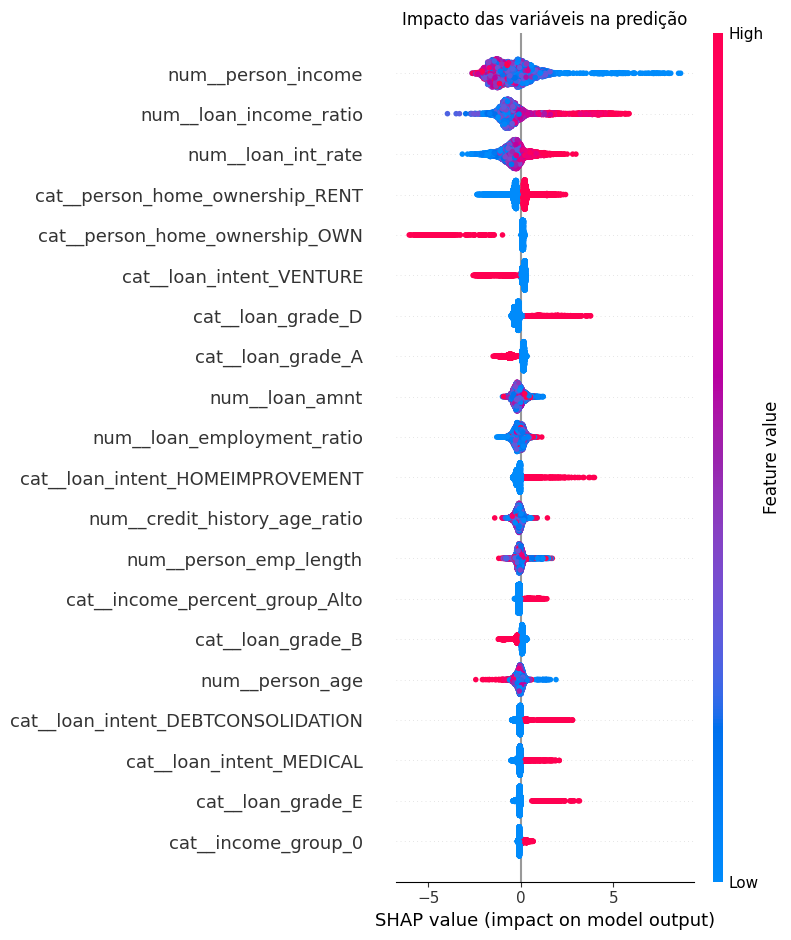

In [202]:
shap.summary_plot(shap_values, X_test_transformed, show=False)
plt.title("Impacto das variáveis na predição")
plt.tight_layout()
plt.show()


**Leitura:** no gráfico de impacto das variáveis, cada ponto é um cliente do conjunto de teste; a posição no eixo X mostra se aquele valor da variável impactou a predição para maior (`+`, mais à direita) ou menor (`-`, mais à esquerda) risco de inadimplência, e a cor mostra se o valor da variável era alto (vermelho) ou baixo (azul) para aquele cliente. Essa análise permite entender quais fatores mais influenciam as decisões do modelo e verificar se os padrões identificados na Análise Exploratória de Dados (Seção 3.2.4), exemplo: como maior comprometimento da renda e taxas de juros mais elevadas aumentando o risco de inadimplência, foram realmente aprendidos pelo modelo, e não são apenas relações observadas nos dados.

### 9.2 Explicabilidade local

Explicação individual para dois casos de interesse de negócio: (i) o cliente com **maior probabilidade prevista de inadimplência** entre os classificados corretamente, e (ii) um **falso negativo** (inadimplente que o modelo previu como adimplente): o tipo de erro mais custoso para o negócio.

In [203]:
proba_test = fitted_model.predict_proba(X_test_transformed)[:, 1]
y_pred_test = best_tree.predict(X_test)

# (i) Caso de alto risco corretamente identificado
idx_high_risk = np.argsort(proba_test)[::-1][0]

# (ii) Falso negativo: real = 1 (inadimplente), previsto = 0 (adimplente)
fn_mask = (y_test.values == 1) & (y_pred_test == 0)
idx_fn = np.where(fn_mask)[0][0] if fn_mask.sum() > 0 else None

print("Índice (posição) do cliente de maior risco previsto:", idx_high_risk, "| proba:", round(proba_test[idx_high_risk], 3))
if idx_fn is not None:
    print("Índice (posição) de um falso negativo:", idx_fn, "| proba:", round(proba_test[idx_fn], 3))


Índice (posição) do cliente de maior risco previsto: 5110 | proba: 1.0
Índice (posição) de um falso negativo: 19 | proba: 0.059


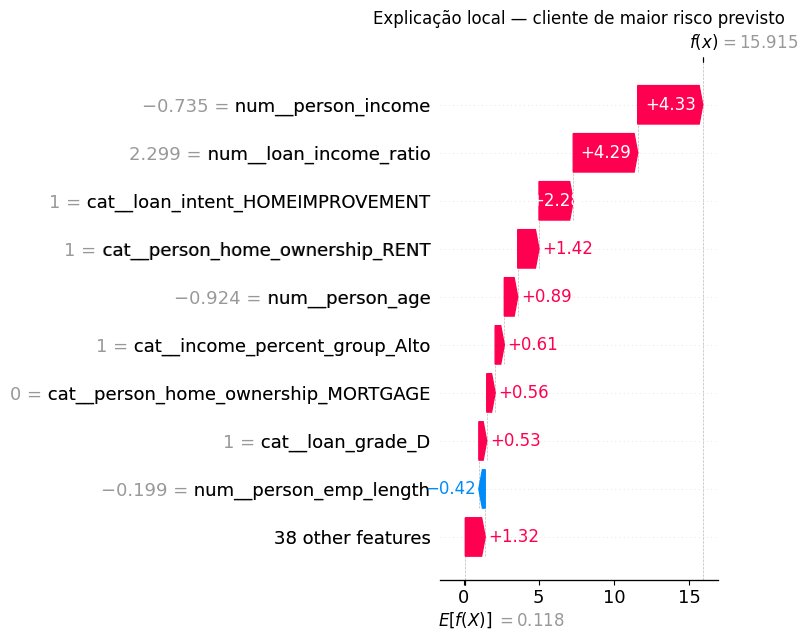

In [204]:
shap.plots.waterfall(shap_values[idx_high_risk], show=False)
plt.title("Explicação local — cliente de maior risco previsto")
plt.tight_layout()
plt.show()


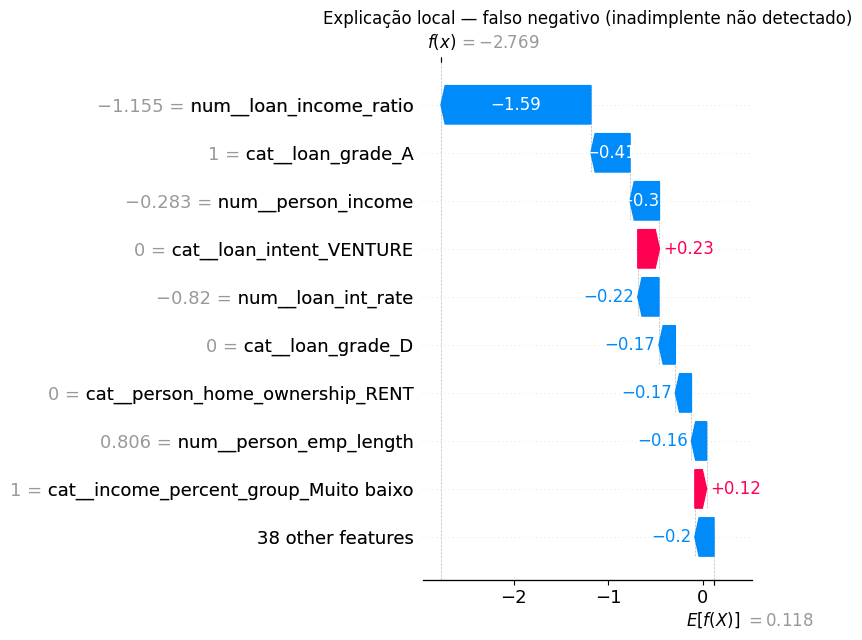

In [205]:
if idx_fn is not None:
    shap.plots.waterfall(shap_values[idx_fn], show=False)
    plt.title("Explicação local — falso negativo (inadimplente não detectado)")
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum falso negativo encontrado no conjunto de teste para este modelo.")


**Leitura de negócio:** o gráfico *waterfall* decompõe a predição de cada cliente a partir de um valor-base (a probabilidade média do conjunto de treino) até a probabilidade final prevista, mostrando exatamente quais variáveis e em qual magnitude, contribuíram para elevar ou reduzir o risco daquele cliente específico. É esse tipo de saída que viabiliza, na prática, justificar uma decisão de crédito automatizada para as áreas de Risco/Compliance e, potencialmente, para o próprio cliente (ex.: atendimento a requisitos de explicabilidade de decisões automatizadas).

### 9.3 Confronto: coeficientes da Regressão Logística vs. SHAP do modelo em árvore

Para concluir o confronto proposto no objetivo do MVP, compara-se o ranking de importância de variáveis segundo os dois paradigmas de explicabilidade: os **coeficientes padronizados** da Regressão Logística (interpretação nativa, mas assume relação linear/aditiva) e a **importância média |SHAP|** do modelo em árvore (não assume linearidade, captura interações).

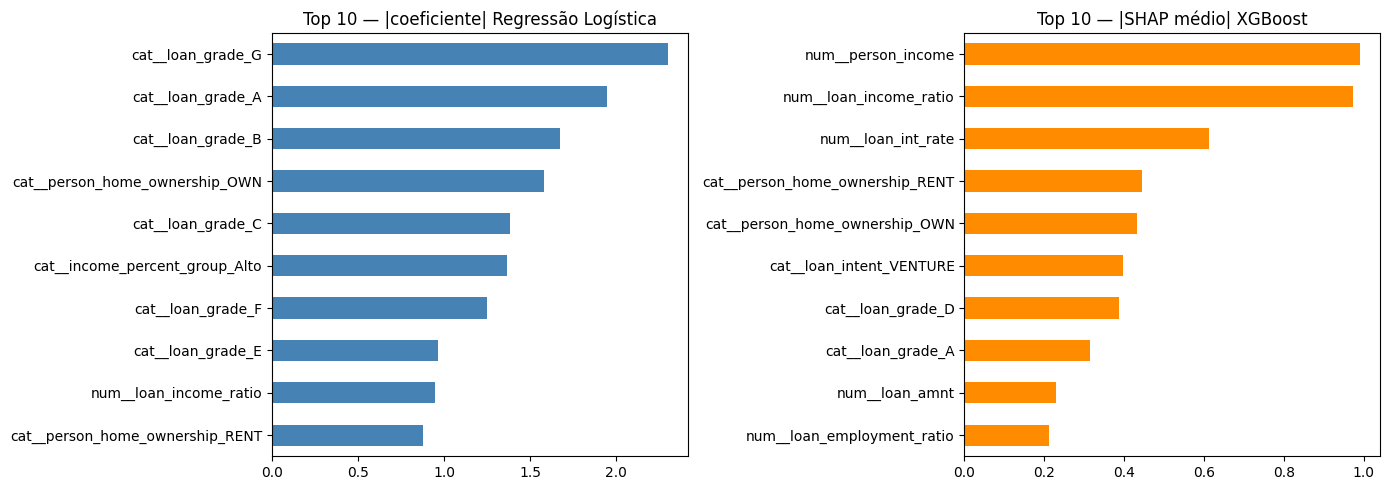

In [206]:
# Coeficientes da Regressão Logística (já em escala padronizada, pois o preprocess usa StandardScaler)
lr_feature_names = best_lr.named_steps["pre"].get_feature_names_out()
lr_coefs = pd.Series(best_lr.named_steps["model"].coef_[0], index=lr_feature_names)
lr_importance = lr_coefs.abs().sort_values(ascending=False).head(10)

# Importância média |SHAP| do modelo em árvore
shap_importance = pd.Series(
    np.abs(shap_values.values).mean(axis=0), index=feature_names
).sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
lr_importance.sort_values().plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Top 10 — |coeficiente| Regressão Logística")

shap_importance.sort_values().plot(kind="barh", ax=axes[1], color="darkorange")
axes[1].set_title(f"Top 10 — |SHAP médio| {best_name}")
plt.tight_layout()
plt.show()


**Interpretação dos Resultados:** A convergência entre parte das variáveis mais importantes nos dois modelos reforça a evidência de que fatores como renda, comprometimento da renda e classificação do empréstimo exercem influência consistente sobre o risco de inadimplência, independentemente do algoritmo utilizado. Por outro lado, as diferenças observadas entre os rankings sugerem que o XGBoost foi capaz de capturar relações não lineares e interações entre variáveis que a Regressão Logística, por sua natureza linear, não representa sem engenharia adicional de atributos. Nesse contexto, o SHAP mostrou-se uma ferramenta eficaz para interpretar um modelo mais complexo, fornecendo explicações tanto globais quanto locais sobre as predições. Dessa forma, os resultados deste MVP indicam que é possível obter ganhos de desempenho preditivo com modelos baseados em árvores sem comprometer a transparência necessária para compreender os fatores que influenciam as decisões do modelo.


## 10 Boas práticas e rastreabilidade

- **Baseline** (`DummyClassifier`) usado como piso de comparação para todos os modelos.
- **Pipelines** (`ColumnTransformer` + modelo) usados de ponta a ponta para evitar vazamento de dados entre treino e teste, inclusive durante a validação cruzada.
- **Semente global (`SEED=42`)** fixada em todos os pontos de aleatoriedade (split, modelos, busca de hiperparâmetros).
- **Decisões de projeto documentadas** em texto ao longo do notebook: remoção de outliers implausíveis (Seção 3.2.1), remoção de variáveis por multicolinearidade (Seção 3.2.5), exclusão das faixas categóricas do conjunto de *features* (Seção 4), tratamento de desbalanceamento via `class_weight`/`scale_pos_weight` (Seção 6).



## 11 Conclusões e próximos passos

Este MVP comparou um modelo tradicional (Regressão Logística) a modelos baseados em árvore, com destaque para XGBoost e LightGBM, na tarefa de classificação de inadimplência, e demonstrou, via SHAP, que é possível obter explicabilidade global e local de um modelo não linear em um nível comparável ao de um modelo linear, sem abrir mão do ganho de performance preditiva observado (Seção 6.1/8).

**Próximos passos sugeridos:**
- Reexecutar o framework **sem** a variável `loan_grade` para medir o ganho preditivo genuíno do modelo.
- Avaliar calibração das probabilidades (`CalibratedClassifierCV`) se as probabilidades forem usadas diretamente para precificação/limite de crédito, e não apenas para ranquear risco.
- Validar estabilidade temporal do modelo (*backtesting* por safra), caso uma variável de tempo/safra esteja disponível em um dataset real de produção.
- Testar estratégias adicionais de regularização e otimização de hiperparâmetros, como ajuste da profundidade das árvores, regularização (L1/L2), subsampling e early stopping, com o objetivo de reduzir o sobreajuste sem comprometer o desempenho preditivo.
- Formalizar o ponto de corte (threshold) da Seção 8.1 junto à área de negócio, com base no custo esperado de Falsos Positivos vs. Falsos Negativos.


## 12. Salvando artefatos (modelo e pipeline)

In [207]:
import joblib

joblib.dump(best_tree, f"modelo_{best_name.lower()}_final.pkl")
joblib.dump(best_lr, "modelo_logistic_regression_final.pkl")

print("Modelos salvos:")
print(f" - modelo_{best_name.lower()}_final.pkl")
print(" - modelo_logistic_regression_final.pkl")


Modelos salvos:
 - modelo_xgboost_final.pkl
 - modelo_logistic_regression_final.pkl
